In [1]:
from pathlib import Path
import backtest

EXPERIMENT    = "industrials_ic"       # matches results/final_<NAME>_reg.ubj
SECTORS       =  ["industrials"]        # None = all sectors
TOP_QUANTILE  = 0.2
BOT_QUANTILE  = 0                 # 0 = long-only
REBALANCE     = "fixed"               # "fixed" | "staggered"
MAX_HOLD_DAYS = 548                   # staggered cap only
MIN_STOCKS    = 3
OUTPUT_DIR    = Path("backtest_results")

In [2]:
df = backtest.load_dataset(SECTORS)
START, END = backtest.infer_test_window(df)
print(f"Test window: {START}  →  {END}")

Dataset: 20,643 rows | 498 tickers
Test window: 2023-05-15  →  2025-05-15


Loaded  final_industrials_ic_reg.ubj  (100 feats | train IC=0.0979 ICIR=1.4932)
Dataset: 20,643 rows | 498 tickers
Features available for inference: 100

Backtest  2023Q2 → 2025Q2  (9 Qs)  mode=fixed  long=20%  short=0%

Sector baseline ETF: XLI


Quarters:  11%|█         | 1/9 [00:01<00:14,  1.83s/it]

  2023Q2  n=443→ 89  long=-1.96%  comb=-1.96%  SPY≈-3.26% sector≈-6.08%


Quarters:  22%|██▏       | 2/9 [00:02<00:07,  1.05s/it]

  2023Q3  n=440→ 88  long=+15.35%  comb=+15.35%  SPY≈+11.06% sector≈+13.02%


...

  2024Q3  n=478→ 96  long=+7.90%  comb=+7.90%  SPY≈+2.49% sector≈-2.23%


Quarters:  78%|███████▊  | 7/9 [00:04<00:01,  1.96it/s]

  2024Q4  n=482→ 97  long=-12.97%  comb=-12.97%  SPY≈-4.27% sector≈-0.22%


Quarters: 100%|██████████| 9/9 [00:05<00:00,  1.69it/s]


  2025Q1  n=492→ 99  long=+17.40%  comb=+17.40%  SPY≈+10.78% sector≈+12.89%
  2025Q2  n= 60→ 12  long=+2.23%  comb=+2.23%  SPY≈+8.12% sector≈+4.98%
Risk-free rates loaded: mean=1.112%/qtr  (4.45% annualised)

─── Backtest Summary ────────────────────────────────────────────────
  Mode                  : fixed
  Risk-free rate (avg)  : 4.78%/yr  (^IRX T-bill)
  Quarters with results : 9 / 9
  Mean cohort IC        : +0.1004  (std=0.0646)
  Mean tail IC (all)   : -0.0803  (std=0.1203)
  Mean tail IC (long)   : -0.0803  (std=0.1203)

  Long leg
    Mean qtrly return   : +5.38%
    Annualised Sharpe   : 0.865
    Win rate            : 66.7%
    Max drawdown        : -12.97%

  Combined L/S
    Mean qtrly return   : +5.38%
    Annualised Sharpe   : 0.865
    Total return        : +54.68%
    Max drawdown        : -12.97%

  SPY benchmark (per-position avg window)
    Mean qtrly return   : +5.12%
    Annualised Sharpe   : 1.341
    Total return        : +54.71%
    Max drawdown        : -4.2

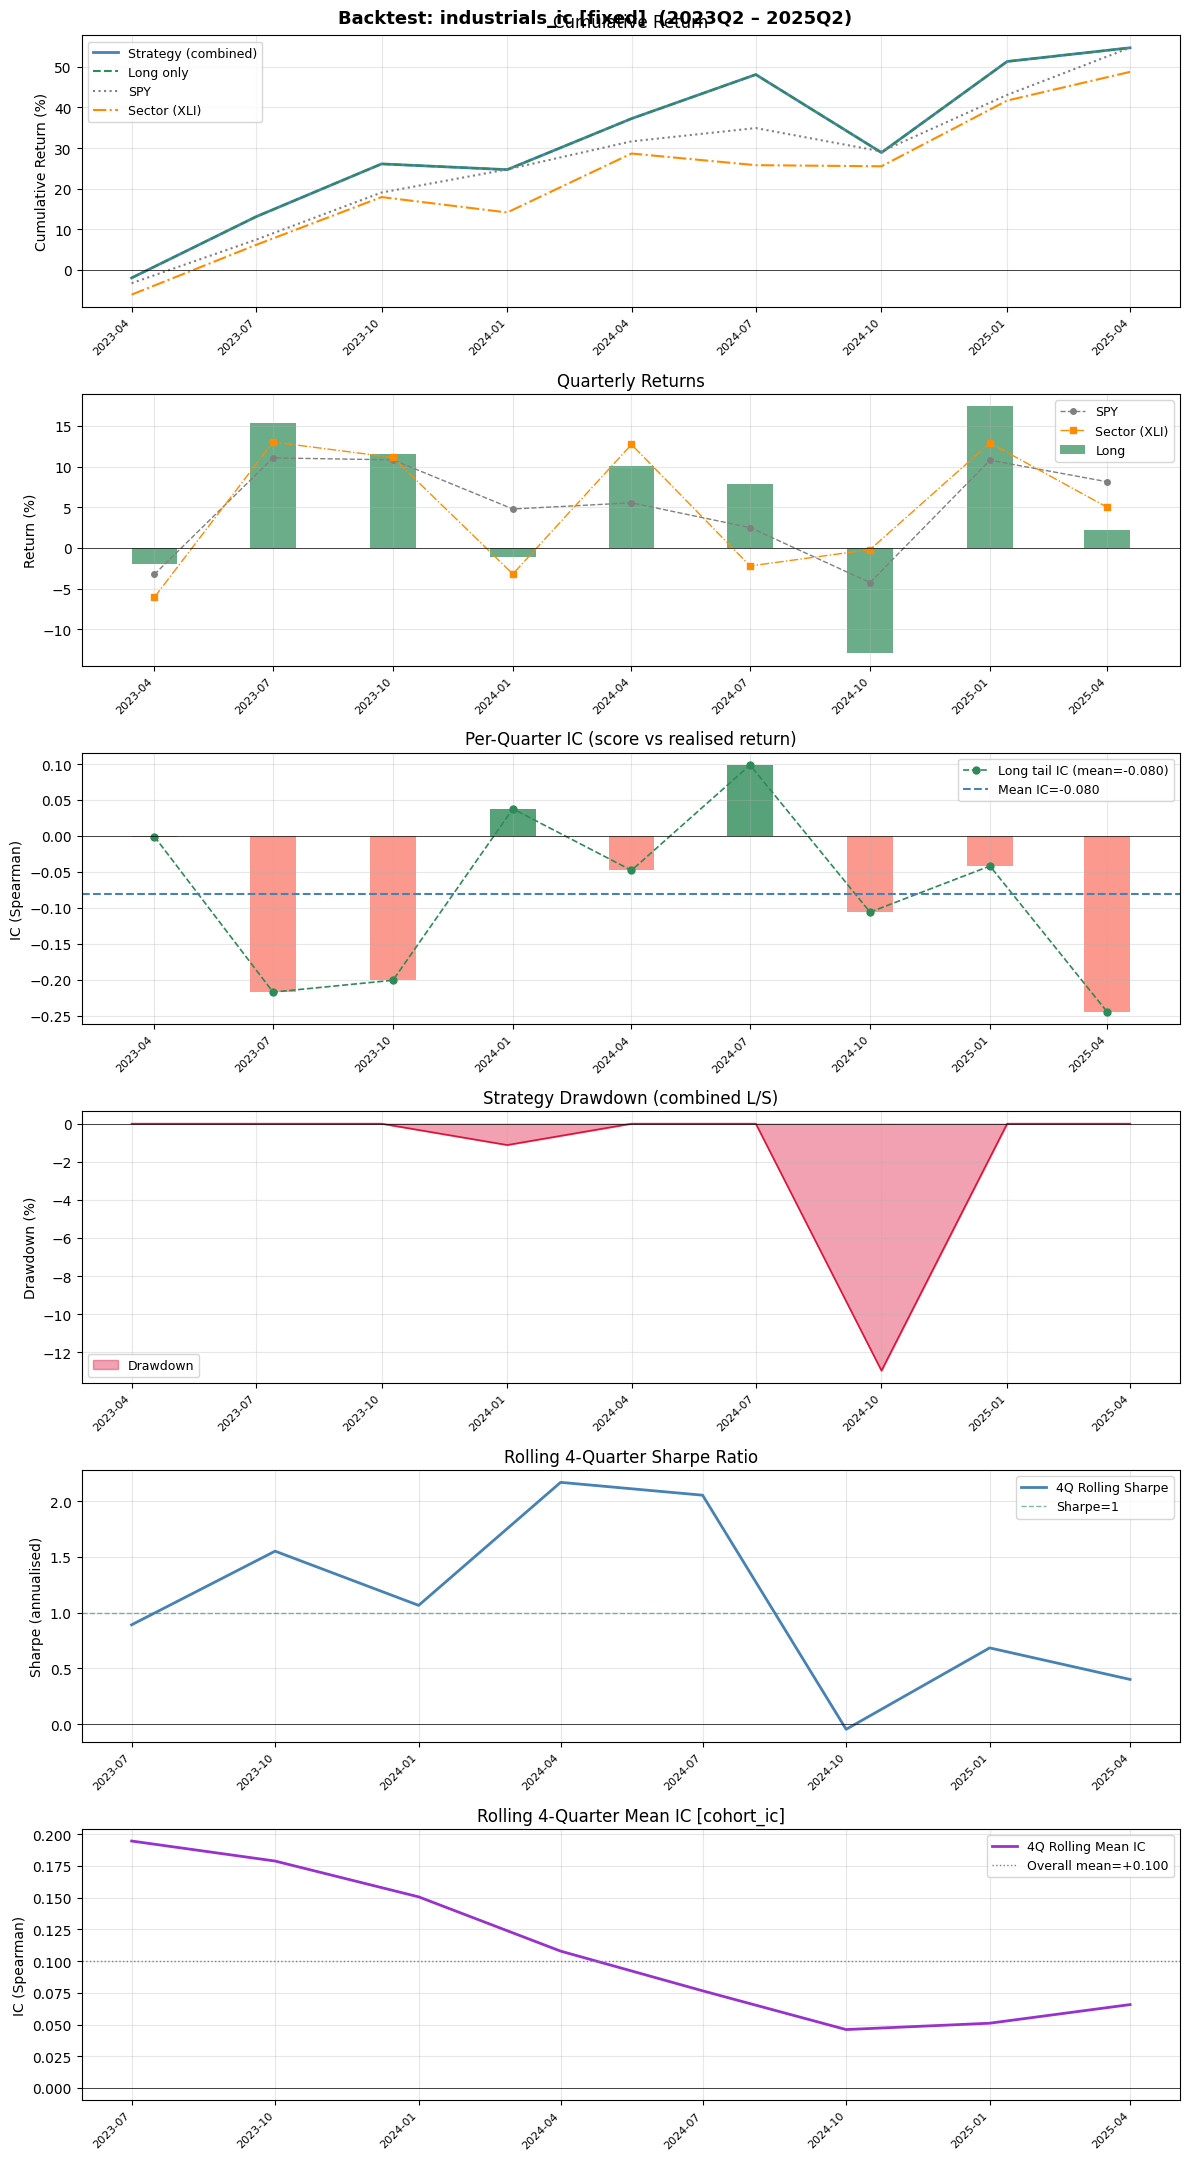

In [3]:
results = backtest.run_backtest(
    experiment_name = EXPERIMENT,
    sectors         = SECTORS,
    top_q           = TOP_QUANTILE,
    bot_q           = BOT_QUANTILE,
    start_date      = START,
    end_date        = END,
    rebalance_mode  = REBALANCE,
    max_hold_days   = MAX_HOLD_DAYS,
    min_stocks      = MIN_STOCKS,
    output_dir      = OUTPUT_DIR,
)